In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r'telecom_churn_data.csv')

In [5]:
cat = df.select_dtypes(include=["object", "category"]).columns
num = df.select_dtypes(include=["number"]).columns

In [7]:
print(f"Churn Data have {df.shape[0]} rows and {df.shape[1]} columns")

Churn Data have 2000 rows and 16 columns


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    2000 non-null   int64  
 1   customer_id             2000 non-null   int64  
 2   phone_no                2000 non-null   object 
 3   gender                  1976 non-null   object 
 4   age                     2000 non-null   int64  
 5   no_of_days_subscribed   2000 non-null   int64  
 6   multi_screen            2000 non-null   object 
 7   mail_subscribed         2000 non-null   object 
 8   weekly_mins_watched     2000 non-null   float64
 9   minimum_daily_mins      2000 non-null   float64
 10  maximum_daily_mins      2000 non-null   float64
 11  weekly_max_night_mins   2000 non-null   int64  
 12  videos_watched          2000 non-null   int64  
 13  maximum_days_inactive   1972 non-null   float64
 14  customer_support_calls  2000 non-null   

In [11]:
df.columns

Index(['year', 'customer_id', 'phone_no', 'gender', 'age',
       'no_of_days_subscribed', 'multi_screen', 'mail_subscribed',
       'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins',
       'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive',
       'customer_support_calls', 'churn'],
      dtype='object')

In [13]:
df.head()

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2015,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2015,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2015,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2015,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


In [15]:
df.tail()

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
1995,2015,997132,385-7387,Female,54,75,no,yes,182.25,11.3,20.66,97,5,4.0,2,NaN
1996,2015,998086,383-9255,Male,45,127,no,no,273.45,9.3,30.99,116,3,3.0,1,0.0
1997,2015,998474,353-2080,NaN,53,94,no,no,128.85,15.6,14.60,110,16,5.0,0,0.0
1998,2015,998934,359-7788,Male,40,94,no,no,178.05,10.4,20.18,100,6,NaN,3,0.0
1999,2015,999961,414-1496,Male,37,73,no,no,326.70,10.3,37.03,89,6,3.0,1,1.0


In [17]:
df.dtypes

year                        int64
customer_id                 int64
phone_no                   object
gender                     object
age                         int64
no_of_days_subscribed       int64
multi_screen               object
mail_subscribed            object
weekly_mins_watched       float64
minimum_daily_mins        float64
maximum_daily_mins        float64
weekly_max_night_mins       int64
videos_watched              int64
maximum_days_inactive     float64
customer_support_calls      int64
churn                     float64
dtype: object

In [19]:
df.isnull().sum()

year                       0
customer_id                0
phone_no                   0
gender                    24
age                        0
no_of_days_subscribed      0
multi_screen               0
mail_subscribed            0
weekly_mins_watched        0
minimum_daily_mins         0
maximum_daily_mins         0
weekly_max_night_mins      0
videos_watched             0
maximum_days_inactive     28
customer_support_calls     0
churn                     35
dtype: int64

In [21]:
df["maximum_days_inactive"] = df["maximum_days_inactive"].fillna(df["maximum_days_inactive"].median())

In [23]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [25]:
df.isnull().sum()

year                       0
customer_id                0
phone_no                   0
gender                     0
age                        0
no_of_days_subscribed      0
multi_screen               0
mail_subscribed            0
weekly_mins_watched        0
minimum_daily_mins         0
maximum_daily_mins         0
weekly_max_night_mins      0
videos_watched             0
maximum_days_inactive      0
customer_support_calls     0
churn                     35
dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    2000 non-null   int64  
 1   customer_id             2000 non-null   int64  
 2   phone_no                2000 non-null   object 
 3   gender                  2000 non-null   object 
 4   age                     2000 non-null   int64  
 5   no_of_days_subscribed   2000 non-null   int64  
 6   multi_screen            2000 non-null   object 
 7   mail_subscribed         2000 non-null   object 
 8   weekly_mins_watched     2000 non-null   float64
 9   minimum_daily_mins      2000 non-null   float64
 10  maximum_daily_mins      2000 non-null   float64
 11  weekly_max_night_mins   2000 non-null   int64  
 12  videos_watched          2000 non-null   int64  
 13  maximum_days_inactive   2000 non-null   float64
 14  customer_support_calls  2000 non-null   

In [29]:
for col in cat[1:]:
    print(col,df[col].unique())

gender ['Female' 'Male']
multi_screen ['no' 'yes']
mail_subscribed ['no' 'yes']


In [31]:
df["gender"] = df["gender"].astype(str).str.strip().str.lower()

df["multi_screen"] = df["multi_screen"].astype(str).str.strip().str.lower()

df["mail_subscribed"] = df["mail_subscribed"].astype(str).str.strip().str.lower()

In [33]:
df["multi_screen"] = df["multi_screen"].replace("maybe", None)

In [35]:
print(df["churn"].value_counts(dropna=False))

churn
0.0    1703
1.0     262
NaN      35
Name: count, dtype: int64


In [37]:
for col in df.columns:
    print(col)
    print(df[col].value_counts(dropna=False).head())
    print("------")

year
year
2015    2000
Name: count, dtype: int64
------
customer_id
customer_id
530490    2
100198    1
706662    1
711697    1
711328    1
Name: count, dtype: int64
------
phone_no
phone_no
409-8743    1
419-5505    1
418-9385    1
347-1914    1
360-6309    1
Name: count, dtype: int64
------
gender
gender
male      1077
female     923
Name: count, dtype: int64
------
age
age
36    104
38    102
35     97
37     94
34     86
Name: count, dtype: int64
------
no_of_days_subscribed
no_of_days_subscribed
86    28
99    26
87    26
93    25
92    24
Name: count, dtype: int64
------
multi_screen
multi_screen
no     1802
yes     198
Name: count, dtype: int64
------
mail_subscribed
mail_subscribed
no     1430
yes     570
Name: count, dtype: int64
------
weekly_mins_watched
weekly_mins_watched
231.00    7
213.45    6
235.65    6
251.70    5
290.70    5
Name: count, dtype: int64
------
minimum_daily_mins
minimum_daily_mins
11.3    38
9.5     37
11.4    36
11.1    34
10.9    33
Name: count, dtype

In [43]:
print("Unique Customer Id :",df["customer_id"].nunique())
print()
print("Unique Phone No :",df["phone_no"].nunique())

Unique Customer Id : 1999

Unique Phone No : 2000


In [45]:
df = df.drop(columns=["customer_id", "phone_no"])

In [47]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

year


In [49]:
df = df.drop(columns=["year"])

In [51]:
df["gender"].value_counts()

gender
male      1077
female     923
Name: count, dtype: int64

In [53]:
df["gender"].value_counts(normalize=True) * 100

gender
male      53.85
female    46.15
Name: proportion, dtype: float64

In [55]:
for col in cat[1:]:
    print(f"\nColumn:{col}")
    print(df[col].value_counts())
    print()
    print(df[col].value_counts(normalize=True)*100)


Column:gender
gender
male      1077
female     923
Name: count, dtype: int64

gender
male      53.85
female    46.15
Name: proportion, dtype: float64

Column:multi_screen
multi_screen
no     1802
yes     198
Name: count, dtype: int64

multi_screen
no     90.1
yes     9.9
Name: proportion, dtype: float64

Column:mail_subscribed
mail_subscribed
no     1430
yes     570
Name: count, dtype: int64

mail_subscribed
no     71.5
yes    28.5
Name: proportion, dtype: float64


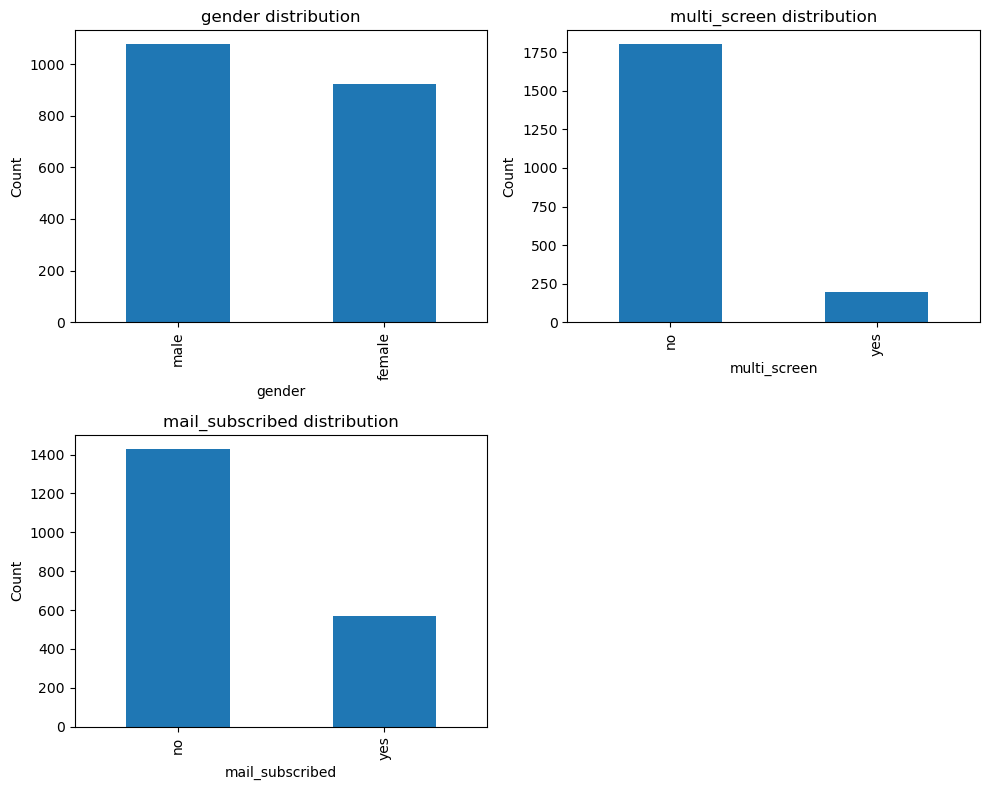

In [57]:
plt.figure(figsize=(10,8))

for i, col in enumerate(cat[1:], 1):
    plt.subplot(2, 2, i)
    df[col].value_counts().plot(kind="bar")
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

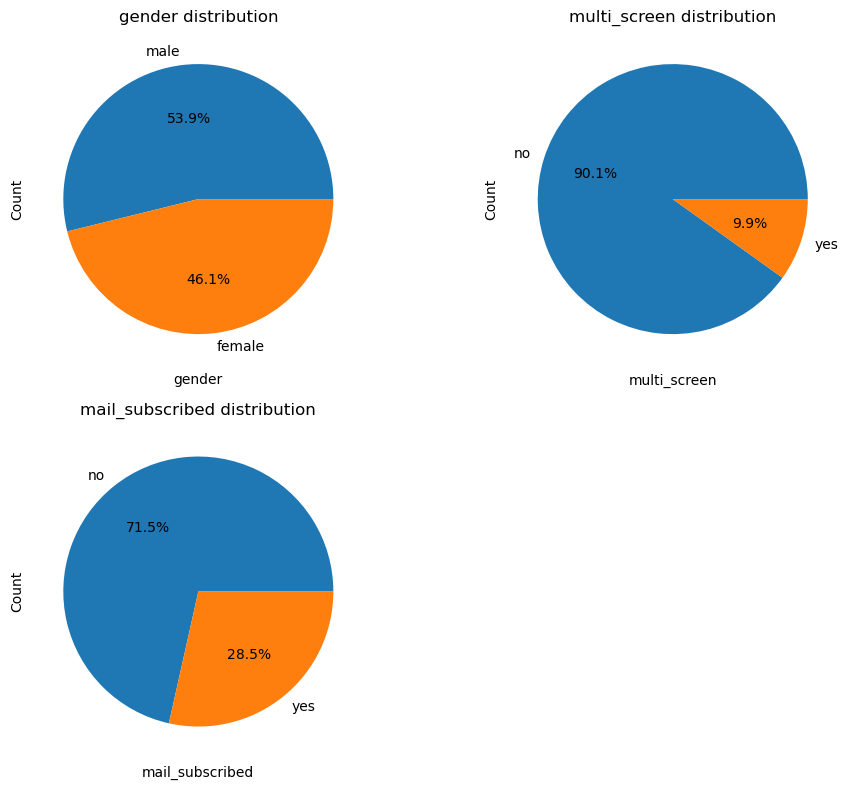

In [61]:
plt.figure(figsize=(10,8))

for i, col in enumerate(cat[1:], 1):
    plt.subplot(2, 2, i)
    df[col].value_counts().plot(kind="pie",autopct="%1.1f%%")
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [63]:
cat = df.select_dtypes(include=["object", "category"]).columns
num = df.select_dtypes(include=["number"]).columns

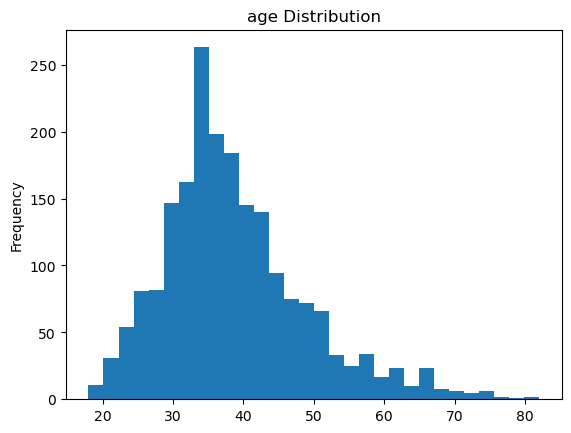

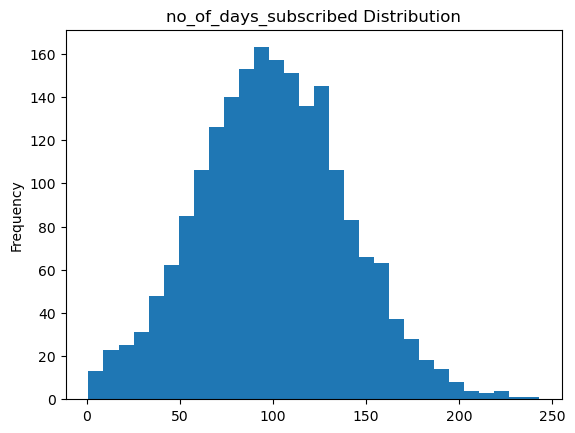

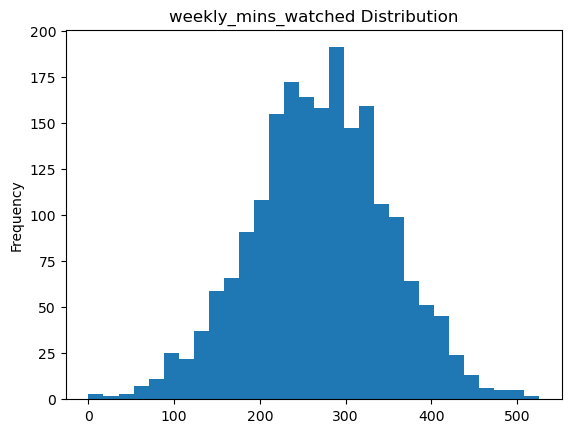

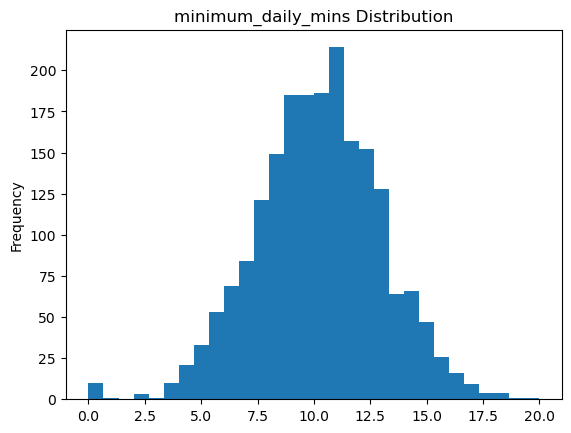

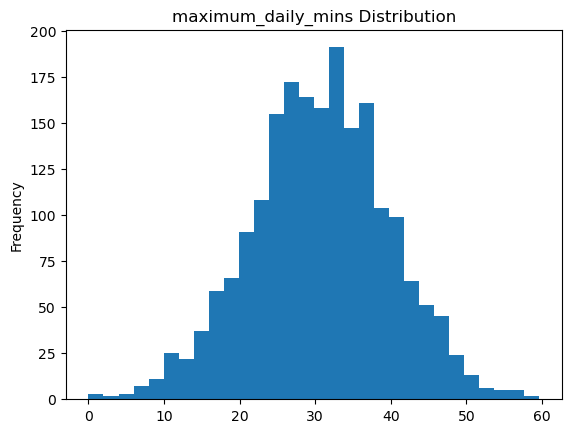

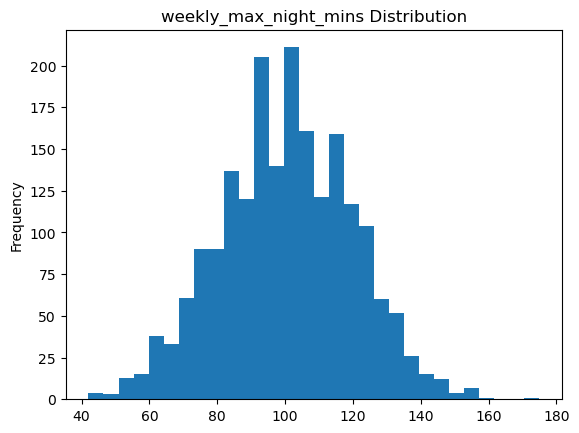

In [65]:
for i, col in enumerate(num):
    if df[col].nunique()>20:
        df[col].plot(kind="hist",bins=30)
        plt.title(f"{col} Distribution")
        plt.show()   

In [69]:
print(df[col].describe())
print()
print("Skewness:", df[col].skew())  

count    1965.000000
mean        0.133333
std         0.340021
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: churn, dtype: float64

Skewness: 2.158925871116794


In [71]:
df[col] = np.log1p(df[col])

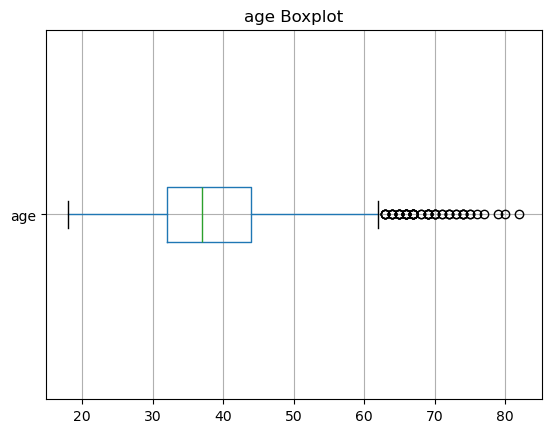

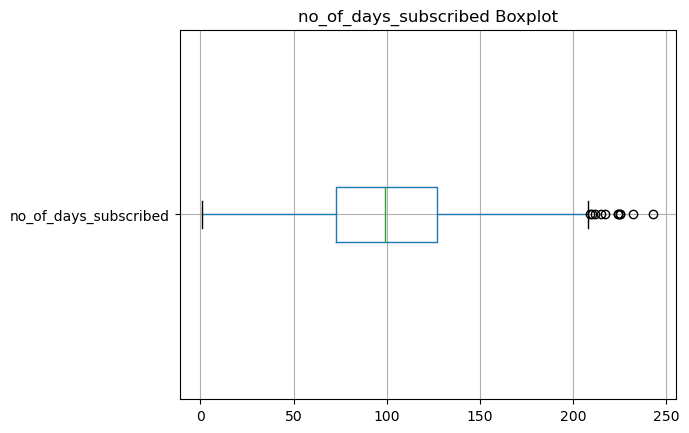

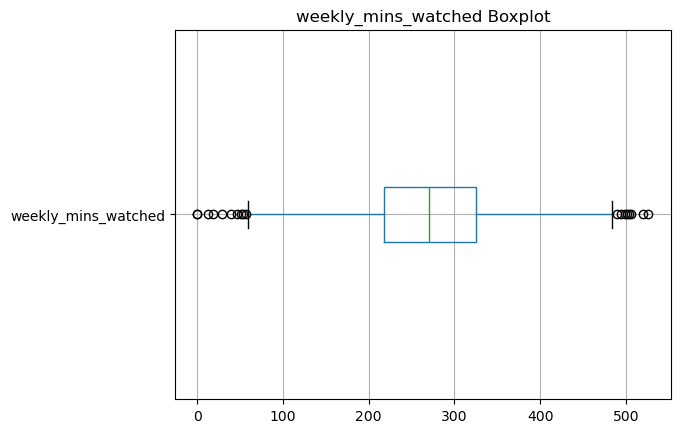

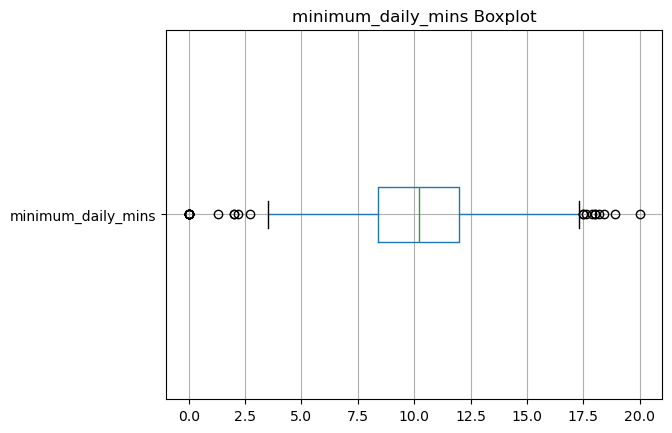

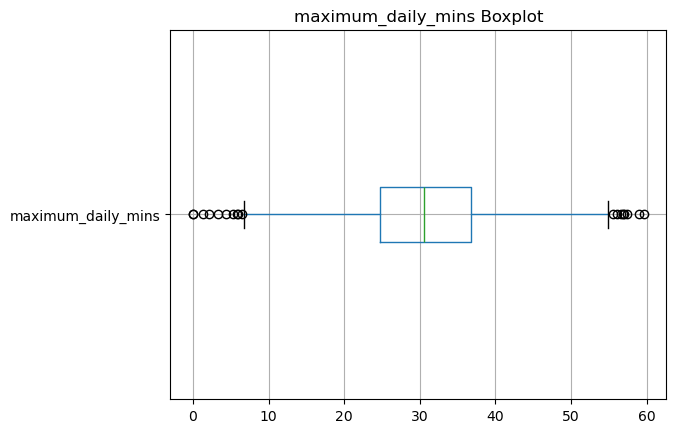

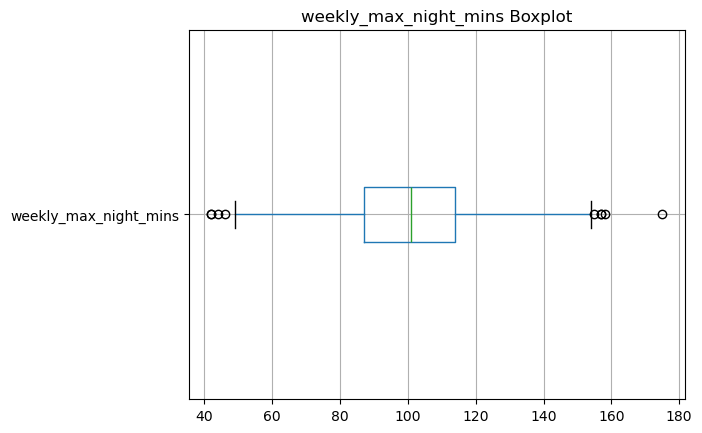

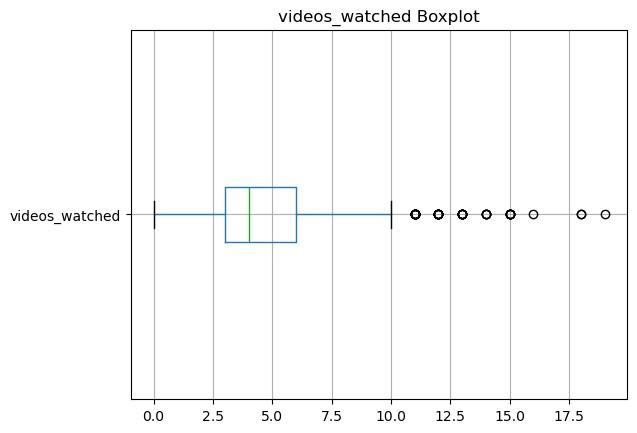

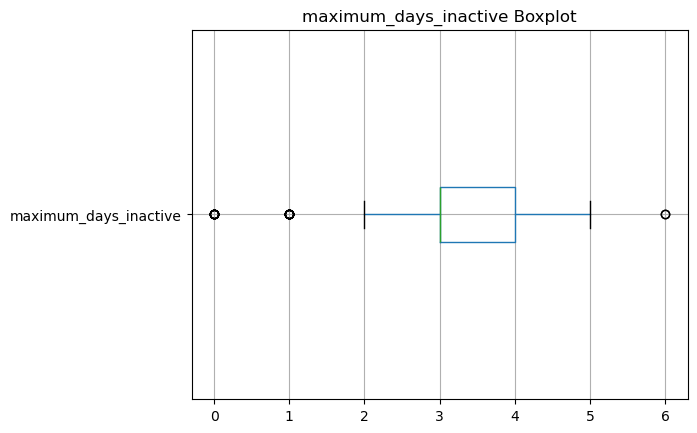

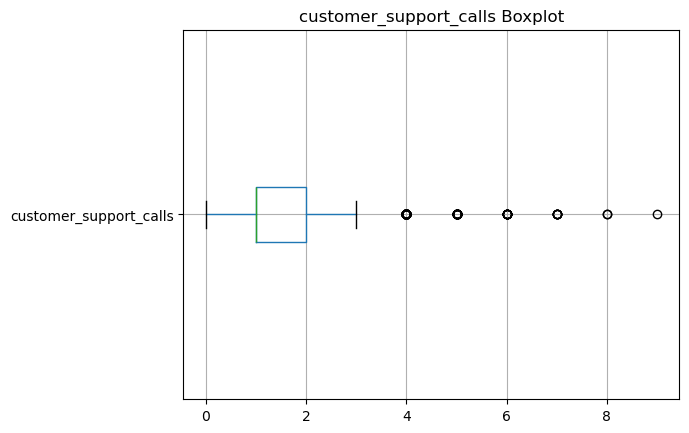

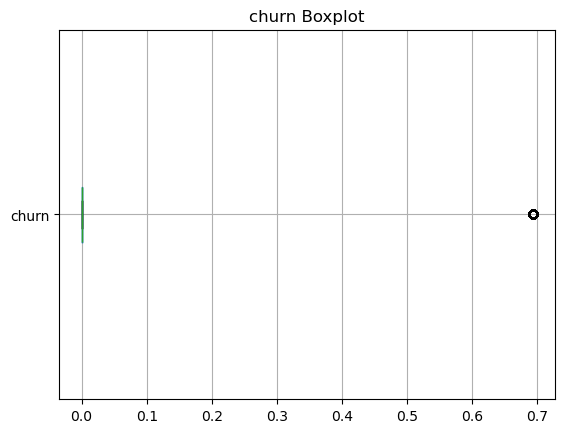

In [73]:
for col in num:
    df.boxplot(column=col,vert=False)
    plt.title(f"{col} Boxplot")
    plt.show() 

In [75]:
for col in num:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR

    median = df[col].median()

    df.loc[(df[col]<lb) | (df[col] > ub),col] = median

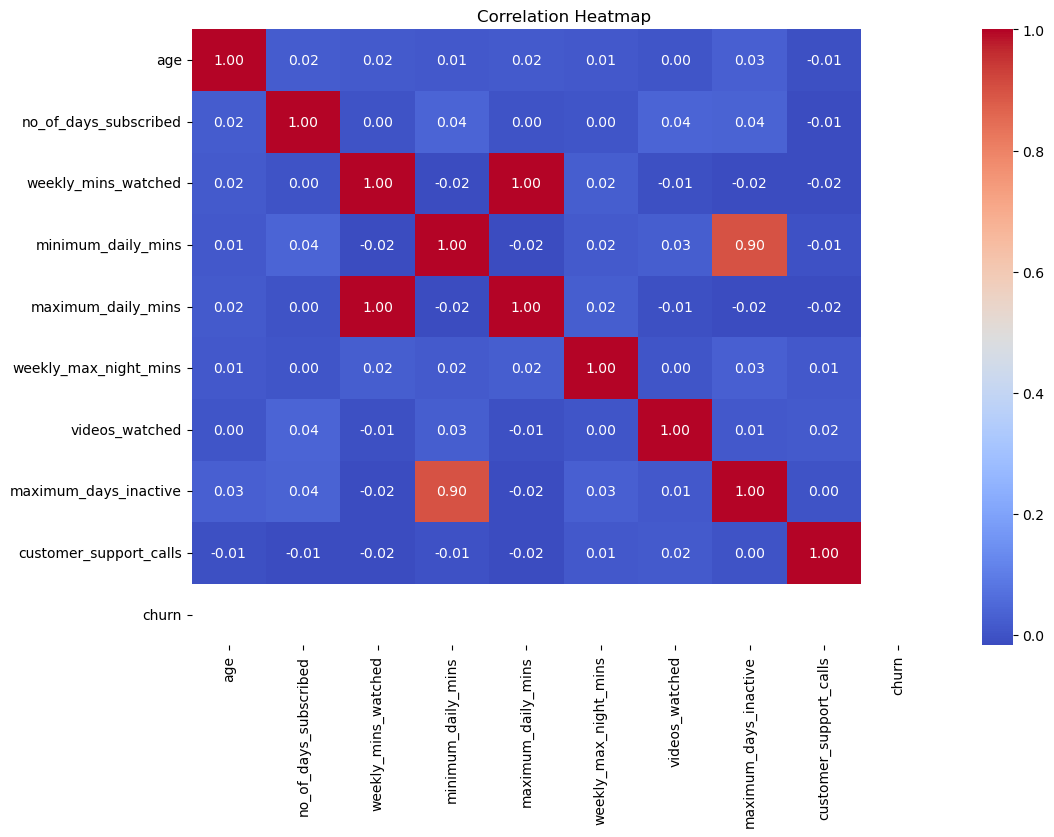

In [77]:
corr_matrix = df[num].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat:
    df[col] = le.fit_transform(df[col])

In [81]:
df = pd.get_dummies(df, columns=cat, drop_first=True)

In [83]:
df

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,gender_1,multi_screen_1,mail_subscribed_1
0,36,62,148.35,12.2,16.81,82,1,4.0,1,0.0,False,False,False
1,39,149,294.45,7.7,33.37,87,3,3.0,2,0.0,False,False,False
2,37,126,87.30,11.9,9.89,91,1,4.0,1,0.0,False,False,False
3,24,131,321.30,9.5,36.41,102,4,3.0,3,0.0,False,False,True
4,40,191,243.00,10.9,27.54,83,7,3.0,1,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,54,75,182.25,11.3,20.66,97,5,4.0,2,NaN,False,False,True
1996,45,127,273.45,9.3,30.99,116,3,3.0,1,0.0,True,False,False
1997,53,94,128.85,15.6,14.60,110,4,5.0,0,0.0,True,False,False
1998,40,94,178.05,10.4,20.18,100,6,3.0,3,0.0,True,False,False


In [85]:
df = df.dropna(subset=["churn"])

In [87]:
df["churn"].isna().sum()

0

In [89]:
df

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,gender_1,multi_screen_1,mail_subscribed_1
0,36,62,148.35,12.2,16.81,82,1,4.0,1,0.0,False,False,False
1,39,149,294.45,7.7,33.37,87,3,3.0,2,0.0,False,False,False
2,37,126,87.30,11.9,9.89,91,1,4.0,1,0.0,False,False,False
3,24,131,321.30,9.5,36.41,102,4,3.0,3,0.0,False,False,True
4,40,191,243.00,10.9,27.54,83,7,3.0,1,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992,42,119,176.70,7.6,20.03,76,3,3.0,3,0.0,False,False,True
1996,45,127,273.45,9.3,30.99,116,3,3.0,1,0.0,True,False,False
1997,53,94,128.85,15.6,14.60,110,4,5.0,0,0.0,True,False,False
1998,40,94,178.05,10.4,20.18,100,6,3.0,3,0.0,True,False,False


In [91]:
cat = df.select_dtypes(include=["object", "category"]).columns
num = df.select_dtypes(include=["number"]).columns

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[num] = scaler.fit_transform(df[num])

In [95]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[num] = scaler.fit_transform(df[num])

In [97]:
df

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,gender_1,multi_screen_1,mail_subscribed_1
0,0.409091,0.294686,0.209894,0.630435,0.209728,0.314286,0.1,0.666667,0.333333,0.0,False,False,False
1,0.477273,0.714976,0.554064,0.304348,0.553939,0.361905,0.3,0.333333,0.666667,0.0,False,False,False
2,0.431818,0.603865,0.066078,0.608696,0.065891,0.400000,0.1,0.666667,0.333333,0.0,False,False,False
3,0.136364,0.628019,0.617314,0.434783,0.617127,0.504762,0.4,0.333333,1.000000,0.0,False,False,True
4,0.500000,0.917874,0.432862,0.536232,0.432758,0.323810,0.7,0.333333,0.333333,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992,0.545455,0.570048,0.276678,0.297101,0.276658,0.257143,0.3,0.333333,1.000000,0.0,False,False,True
1996,0.613636,0.608696,0.504594,0.420290,0.504469,0.638095,0.3,0.333333,0.333333,0.0,True,False,False
1997,0.795455,0.449275,0.163958,0.876812,0.163791,0.580952,0.4,1.000000,0.000000,0.0,True,False,False
1998,0.500000,0.449275,0.279859,0.500000,0.279776,0.485714,0.6,0.333333,1.000000,0.0,True,False,False


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1965 non-null   float64
 1   no_of_days_subscribed   1965 non-null   float64
 2   weekly_mins_watched     1965 non-null   float64
 3   minimum_daily_mins      1965 non-null   float64
 4   maximum_daily_mins      1965 non-null   float64
 5   weekly_max_night_mins   1965 non-null   float64
 6   videos_watched          1965 non-null   float64
 7   maximum_days_inactive   1965 non-null   float64
 8   customer_support_calls  1965 non-null   float64
 9   churn                   1965 non-null   float64
 10  gender_1                1965 non-null   bool   
 11  multi_screen_1          1965 non-null   bool   
 12  mail_subscribed_1       1965 non-null   bool   
dtypes: bool(3), float64(10)
memory usage: 174.6 KB
